#### Update State mid-execution (Human intervention)

Boilerplate code


In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv
import warnings

warnings.filterwarnings("ignore")

load_dotenv()

google_api_key = os.getenv("../.env/GOOGLE_API_KEY")

google_llm=ChatGoogleGenerativeAI(
    temperature=0,
    model="gemini-3.5-flash-lite",
    api_key=google_api_key,
    max_tokens=200
)


Defining graph


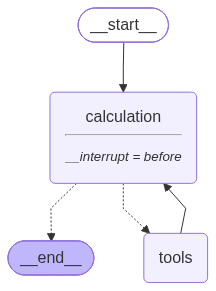

In [5]:
from IPython.display import display,Image
from langchain_core.messages import HumanMessage,AIMessage, SystemMessage
from langgraph.graph import START, END, StateGraph,MessagesState
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.checkpoint.memory import MemorySaver

def add(a : int, b : int) -> int:
    "Adds two numbers A and B"
    return a + b

def subtract(a : int, b : int) -> int:
    "Subtracts two numbers A and B"
    return a - b

def multiply(a : int, b : int) -> int:
    "Multiplies two numbers A and B"
    return a * b

def divide(a : int, b : int) -> int:
    "Divides two numbers A and B"
    return a + b

tools = [add,subtract,multiply,divide]

memory = MemorySaver()

llm_with_tools = google_llm.bind_tools(tools)

sys_message = SystemMessage(
    content="""You are an helpful assisstant with joke minded. Always use given tools for Arithmetic operations while continue your bullying."""
)

def calculation(state : MessagesState):
    return {"messages":[llm_with_tools.invoke([sys_message] + state["messages"])]}

builder = StateGraph(MessagesState)

builder.add_node("calculation",calculation)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"calculation")
builder.add_conditional_edges("calculation",tools_condition)
builder.add_edge("tools","calculation")

graph = builder.compile(interrupt_before=["calculation"], checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))




Graph invoke

In [28]:
config = {"configurable":{"thread_id":128}}

res = graph.invoke({"messages":[
    HumanMessage(
        content="Multiply 10 with 12"
    ),
    
]},config=config)

for r in res["messages"]:
    r.pretty_print()

================================ Human Message =================================

Multiply 10 with 12


In [29]:
# To check the current state of the graph

current_state = graph.get_state(config)
current_state.values

{'messages': [HumanMessage(content='Multiply 10 with 12', additional_kwargs={}, response_metadata={}, id='02661934-1834-4094-8335-2d4b6bac0b4c')]}

.update_state() Method to alter the state during execution

In [30]:
from langchain_core.messages import HumanMessage

new_config = graph.update_state(
    config,
    {"messages":    HumanMessage(
            content="No. multiply 5 with 6 and then add with 10"
        )}
    
)
new_config

{'configurable': {'thread_id': '128',
  'checkpoint_ns': '',
  'checkpoint_id': '1f18d69a-0702-64d2-8001-9352fa01a4c9'}}

In [31]:
# checking state now
current_state = graph.get_state(config)
current_state.values

{'messages': [HumanMessage(content='Multiply 10 with 12', additional_kwargs={}, response_metadata={}, id='02661934-1834-4094-8335-2d4b6bac0b4c'),
  HumanMessage(content='No. multiply 5 with 6 and then add with 10', additional_kwargs={}, response_metadata={}, id='d250aa92-1415-4059-b1a4-808995a10e3d')]}

In [ ]:
for event in graph.stream(None, config=config, stream_mode="values"):
    event["messages"][-1].pretty_print()

# stops after this node ( we need to run one by one again until end)
# to overcome this, go with looping till the LLM output

================================ Human Message =================================

No. multiply 5 with 6 and then add with 10
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (9xAVb0Tx)
 Call ID: 9xAVb0Tx
  Args:
    a: 5
    b: 6
================================= Tool Message =================================
Name: multiply

30


Looping the stream/invoke statements from the paused Node till the Final LLM output

In [32]:
while graph.get_state(config).next:
    state = graph.get_state(config)
    print(f"\nPaused. Next node: {state.next}")
    print(f"\nLast message: {state.values['messages'][-1]}")

    user_approval = input("\nApprove? (yes/No): ")
    if user_approval.lower() == "yes":
        for event in graph.stream(None, config=config, stream_mode="values"):
            event["messages"][-1].pretty_print()
    else:
        print(f"Flow interupted by the user at Node: {state}")
        break



Paused. Next node: ('calculation',)

Last message: content='No. multiply 5 with 6 and then add with 10' additional_kwargs={} response_metadata={} id='d250aa92-1415-4059-b1a4-808995a10e3d'
================================ Human Message =================================

No. multiply 5 with 6 and then add with 10
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (v004qWWG)
 Call ID: v004qWWG
  Args:
    b: 6
    a: 5
================================= Tool Message =================================
Name: multiply

30

Paused. Next node: ('calculation',)

Last message: content='30' name='multiply' id='8f2f7b64-c16d-4c00-893e-513fa2358691' tool_call_id='v004qWWG'
Flow interupted by the user at Node: StateSnapshot(values={'messages': [HumanMessage(content='Multiply 10 with 12', additional_kwargs={}, response_metadata={}, id='02661934-1834-4094-8335-2d4b6bac0b4c'), HumanMessage(content='No. multiply 5 with 6 and then add with 10', addi